In [2]:
from datasets import load_dataset

ds = load_dataset("QCRI/HumAID-all", verification_mode="no_checks")
print(ds)

Generating train split: 100%|█████████████████████████████████████████████████████████████████████████████████████████████| 53531/53531 [00:00<00:00, 927997.52 examples/s]
Generating validation split: 7793 examples [00:00, 487199.45 examples/s]
Generating test split: 100%|██████████████████████████████████████████████████████████████████████████████████████████████| 15160/15160 [00:00<00:00, 419211.95 examples/s]

DatasetDict({
    train: Dataset({
        features: ['tweet_text', 'class_label'],
        num_rows: 53531
    })
    validation: Dataset({
        features: ['tweet_text', 'class_label'],
        num_rows: 7793
    })
    test: Dataset({
        features: ['tweet_text', 'class_label'],
        num_rows: 15160
    })
})


In [3]:
df = ds["train"].to_pandas()  # match whatever split name actually appeared
print(df.shape)
print(df.columns.tolist())
print(df.head())

(53531, 2)
['tweet_text', 'class_label']
                                          tweet_text  \
0  Powerful Ecuador quake kills at least 235: POR...   
1  Im at awe and saddened with the #EcuadorEarthq...   
2  RT @RachelAndJun: Our hearts are with everyone...   
3  RT @noticias2000: Ecuador quake death toll has...   
4  RT @pzf: BREAKING PHOTOS: Major damage reporte...   

                              class_label  
0                  injured_or_dead_people  
1  rescue_volunteering_or_donation_effort  
2                    sympathy_and_support  
3                  injured_or_dead_people  
4       infrastructure_and_utility_damage  


In [4]:
print(df["class_label"].value_counts())
print(df["class_label"].value_counts(normalize=True))

class_label
rescue_volunteering_or_donation_effort    14891
other_relevant_information                 8501
sympathy_and_support                       6250
infrastructure_and_utility_damage          5715
injured_or_dead_people                     5110
not_humanitarian                           4407
caution_and_advice                         3774
displaced_people_and_evacuations           2800
requests_or_urgent_needs                   1833
missing_or_found_people                     250
Name: count, dtype: int64
class_label
rescue_volunteering_or_donation_effort    0.278175
other_relevant_information                0.158805
sympathy_and_support                      0.116755
infrastructure_and_utility_damage         0.106761
injured_or_dead_people                    0.095459
not_humanitarian                          0.082326
caution_and_advice                        0.070501
displaced_people_and_evacuations          0.052306
requests_or_urgent_needs                  0.034242
missing_or_

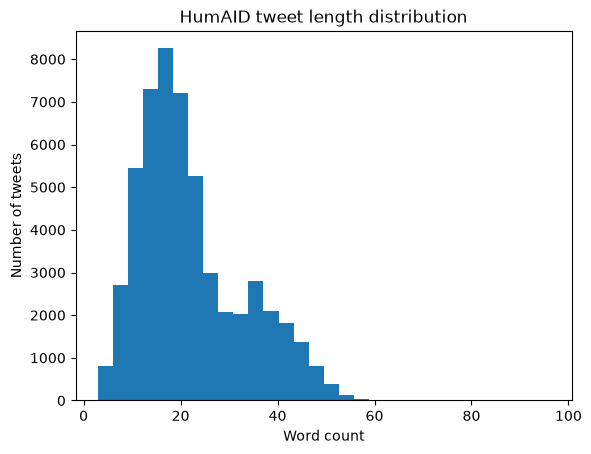

count    53531.000000
mean        22.112458
std         10.708748
min          3.000000
25%         14.000000
50%         19.000000
75%         28.000000
max         96.000000
Name: word_length, dtype: float64


In [5]:
import matplotlib.pyplot as plt

df["word_length"] = df["tweet_text"].str.split().str.len()

plt.hist(df["word_length"], bins=30)
plt.xlabel("Word count")
plt.ylabel("Number of tweets")
plt.title("HumAID tweet length distribution")
plt.show()

print(df["word_length"].describe())

In [6]:
for label in df["class_label"].unique():
    subset = df[df["class_label"] == label]
    print(f"\n=== {label} ({len(subset)} tweets) ===")
    print(subset.sample(min(5, len(subset)))["tweet_text"].tolist())


=== injured_or_dead_people (5110 tweets) ===
['BREAKING: The death toll has reached 42 in the Northern California wildfire, making it the deadliest in state history.', 'Geraldo there is a difference between dying and dead, the death toll is not done, how dare anyone attack #PuertoRico', 'Fourteen wildfires are burning across California, at least 31 people have been killed', 'Mexico says it was hit by its strongest earthquake in 100 years; 5 dead  via @usatoday', 'COMING UP: The death toll continues to rise as those dangerous California wildfires burn out of control. Well have team coverage live from the scene this morning.']

=== rescue_volunteering_or_donation_effort (14891 tweets) ===
['@FeedingAmerica remains on the forefront of disaster relief. In preparation for the impending storm, we (@FeedingNEFL) are prepared to assist not only in our area but also in our sister food banks areas as well. Help will be there in times of crises.', '#news Carnival Corp, Miami Heat will donate up 

In [7]:
counts = df["class_label"].value_counts()
print(counts)
# Flag categories under, say, 5% of total as "rare" for later robustness checks
rare_threshold = len(df) * 0.05
rare_categories = counts[counts < rare_threshold].index.tolist()
print("Rare categories:", rare_categories)

class_label
rescue_volunteering_or_donation_effort    14891
other_relevant_information                 8501
sympathy_and_support                       6250
infrastructure_and_utility_damage          5715
injured_or_dead_people                     5110
not_humanitarian                           4407
caution_and_advice                         3774
displaced_people_and_evacuations           2800
requests_or_urgent_needs                   1833
missing_or_found_people                     250
Name: count, dtype: int64
Rare categories: ['requests_or_urgent_needs', 'missing_or_found_people']


## Phase 2 Summary

- 53,531 tweets, 11 humanitarian categories
- Severe class imbalance: rescue_volunteering_or_donation_effort (27.8%) vs missing_or_found_people (0.47%) — ~60x gap
- Rare categories (<5% of data): requests_or_urgent_needs, missing_or_found_people
- Tweet length: mean 22 words (std 10.7), range 3-96 words — no extreme outliers requiring special truncation
- Manual review found: (1) occasional off-topic/mislabeled tweets (e.g. political commentary tagged as sympathy_and_support), (2) garbled Unicode/emoji encoding in some tweets — both noted as limitations, decision on cleaning deferred to Phase 3
- No event metadata in this dataset version (Harvard Dataverse full version was inaccessible) — rare-category robustness will substitute for the originally-planned event-based distribution-shift analysis